In [1]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 26.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.optimize import minimize

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
plt_df_raw = pd.read_csv('number_of_mouse_ct_found.csv', index_col = 'Unnamed: 0')

In [ ]:
#Loading Data

In [2]:
fn = '../../Active_SAMap_Joined/active_samap/sm_Allen_Full_dr_07162026_ncbi.pkl'
fn_mo = '../../Active_SAMap_Joined/active_samap/sm_mo_03122025_dr_07162026_ncbi.pkl'

In [3]:
org = 'dr'
ref_one = 'mg'
ref_two = 'mo'

In [4]:
sm = load_samap(fn)
sm_mo = load_samap(fn_mo)

In [176]:
#setting mo labels to known labels

In [5]:
level = 'fin_ct'

In [7]:
fin_labs = pd.read_csv('../../Active_SAMap_Joined/MO_subclass_id_label_mapping_boostrap_th9_03192025.csv', index_col = 'Unnamed: 0')

In [8]:
len(fin_labs['fin_ct'].unique())

115

In [9]:
len(fin_labs['fin_ct'][fin_labs['fin_ct'] == 'Unlabeled'])

11176

In [10]:
len(fin_labs)

75330

In [11]:
sm_mo.sams['mo'].adata.obs['subclass_id_label_mapping'] = fin_labs['fin_ct']

In [ ]:
#mapping 

5
75
10
26.862927675247192 seconds to complete 6 precent
10
99
11
55.4012770652771 seconds to complete 13 precent
15
112
12
86.69450688362122 seconds to complete 20 precent
20
123
11
117.04511189460754 seconds to complete 26 precent
25
124
11
148.67152619361877 seconds to complete 33 precent
30
131
13
180.84110307693481 seconds to complete 40 precent
35
142
14
214.18602871894836 seconds to complete 46 precent
40
138
14
248.2234115600586 seconds to complete 53 precent
45
141
15
282.798508644104 seconds to complete 60 precent
50
142
15
318.7373218536377 seconds to complete 66 precent
55
143
15
355.0409309864044 seconds to complete 73 precent
60
145
15
392.4457063674927 seconds to complete 80 precent
65
147
18
431.38328218460083 seconds to complete 86 precent
70
152
18
471.35659432411194 seconds to complete 93 precent
75
149
20
511.7376947402954 seconds to complete 100 precent


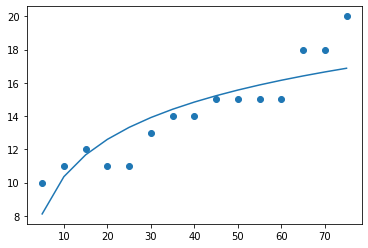

In [16]:
level = 'subclass_id_label'
num_cell_types = []
t0 = time.time()
for reso in range(5,80,5):
    print(reso)
    #clustering the mg to org data
    sm.sams[org].clustering(param = reso)

    # mapping from mg to org data
    keys = {ref_one:level,org:'leiden_clusters'}
    D,MappingTable = get_mapping_scores(sm,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_one)]

    mapping_dict = {}
    for item in lim_MappingTable:
        len_item = len(sm.sams[org].adata[sm.sams[org].adata.obs['leiden_clusters'] == int(item[3:])])
        if len_item > 25:
            mapping_dict[item] = str(lim_MappingTable[item].idxmax())
        else:
            mapping_dict[item] = ref_one + '_Unlabeled'

    #saving new mapping as "temp mapping"
    new_mapping = []
    for item in sm.sams[org].adata.obs['leiden_clusters']:
        new_mapping.append(mapping_dict[org + '_' + str(item)][3:])

    sm_mo.sams[org].adata.obs['temp_mapping'] = new_mapping

    #testing line
    print(sm_mo.sams[org].adata.obs['temp_mapping'].nunique())

    #mapping the mg to org data to the mo data
    keys = {ref_two: level + '_mapping',org:'temp_mapping'}
    D,MappingTable = get_mapping_scores(sm_mo,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_two)]

    #collecting best mappings
    mapping_dict = {}
    for item in lim_MappingTable:
        mapping_dict[item] = str(lim_MappingTable[item].idxmax())


    #checking whether the best mapping is the same in mo and mg
    mapping_dict_mo = {item:'Unlabeled' for item in mapping_dict}
    for item in mapping_dict:
        if item[3:] == mapping_dict[item][3:]:
            mapping_dict_mo[item] = mapping_dict[item][3:]

    #saving the new mapping
    new_mapping_mo = []
    for item in sm_mo.sams[org].adata.obs['temp_mapping']:
        new_mapping_mo.append(mapping_dict_mo[org + '_' + item])

    #testing line
    print(len(set(new_mapping_mo)))

    #finding the "highest quality mapping across resolutions and saving it
    sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)] = new_mapping_mo
    sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)] = sm.sams[org].adata.obs['leiden_clusters']
    num_cell_types.append(sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)].nunique())

    t1 = time.time()
    print(str(t1 - t0) + ' seconds to complete ' + str(int((reso/5)*(100/15))) + ' precent')

x = [i for i in range(5,80,5)]
func = np.polyfit(np.log(x), num_cell_types, 1)
plt.plot([i for i in range(5,80,5)], [func[0] * np.log(i) + func[1] for i in range(5,80,5)])
plt.scatter(x, num_cell_types)
plt.show()

In [20]:
sm.sams['dr'].adata.obs

,n_genes,n_counts,key,leiden_clusters,temp_mapping_subclass_id_label_reso_5,temp_mapping_lc_reso_5,temp_mapping_subclass_id_label_reso_10,temp_mapping_lc_reso_10,temp_mapping_subclass_id_label_reso_15,temp_mapping_lc_reso_15,...,temp_mapping_subclass_id_label_reso_55,temp_mapping_lc_reso_55,temp_mapping_subclass_id_label_reso_60,temp_mapping_lc_reso_60,temp_mapping_subclass_id_label_reso_70,temp_mapping_lc_reso_70,temp_mapping_subclass_id_label_reso_75,temp_mapping_lc_reso_75,subclass_id_label_mapping,subclass_id_label_lc
AAACCTGAGAGTTGGC,496,866.0,DarioRerio1,336,Unlabeled,20,Unlabeled,7,Unlabeled,61,...,Unlabeled,367,Unlabeled,348,Unlabeled,305,Unlabeled,336,Unlabeled,344
AAACCTGAGGTGACCA,491,618.0,DarioRerio1,15,Unlabeled,55,Unlabeled,51,Unlabeled,39,...,Unlabeled,5,Unlabeled,23,Unlabeled,16,Unlabeled,15,Unlabeled,14
AAACCTGCAAGCGTAG,774,1502.0,DarioRerio1,286,Unlabeled,30,Unlabeled,11,Unlabeled,60,...,Unlabeled,251,Unlabeled,96,Unlabeled,285,Unlabeled,286,Unlabeled,338
AAACCTGCAGTAGAGC,929,1417.0,DarioRerio1,126,Unlabeled,17,Unlabeled,5,Unlabeled,0,...,Unlabeled,31,Unlabeled,167,Unlabeled,161,Unlabeled,126,Unlabeled,159
AAACCTGCATCACCCT,702,1262.0,DarioRerio1,160,Unlabeled,3,Unlabeled,45,Unlabeled,34,...,Unlabeled,249,Unlabeled,239,Unlabeled,183,Unlabeled,160,Unlabeled,217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACATGTAAGA,2099,8522.0,DanioRerio16,517,Unlabeled,30,Unlabeled,102,Unlabeled,93,...,Unlabeled,402,Unlabeled,433,Unlabeled,286,Unlabeled,517,Unlabeled,452
TTTGTCACATTATCTC,945,1461.0,DanioRerio16,166,Unlabeled,57,Unlabeled,50,Unlabeled,33,...,Unlabeled,198,Unlabeled,165,Unlabeled,163,Unlabeled,166,Unlabeled,200
TTTGTCAGTCCGAGTC-2,1271,2548.0,DanioRerio16,258,Unlabeled,64,Unlabeled,84,Unlabeled,80,...,Unlabeled,325,Unlabeled,289,Unlabeled,256,Unlabeled,258,Unlabeled,282
TTTGTCAGTGACTACT-1,659,1041.0,DanioRerio16,620,Unlabeled,10,Unlabeled,2,Unlabeled,18,...,Unlabeled,76,Unlabeled,72,Unlabeled,710,Unlabeled,620,Unlabeled,64


In [ ]:
#set value
best_reso = 65

print(best_reso)
sm.sams[org].adata.obs[level + '_mapping'] = sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(best_reso)]
sm.sams[org].adata.obs[level + '_lc'] = sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(best_reso)]
for reso in range(5,80,5):
    print(reso == best_reso)
    if reso != best_reso: 
        sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_' + level + '_reso_' + str(reso), axis = 1)
        sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_lc_reso_' + str(reso), axis = 1)
        
sm.sams[org].adata.obs.to_csv('../../Active_SAMap_Joined/' + org.upper() + '_metadata_subclass_250_unclean_07162026.csv')

In [45]:
for i in range(1,2):
    num_ct_mapped = 0
    t0 = time.time()
    level = 'subclass_id_label'
    num_cell_types = []
    reso = 25
    
    sm = load_samap('sm_Allen_Full_ac_ncbi_soupx_cleaned_03122025_subclass_250_' + str(i)+ '.pkl')
    
    #clustering the mg to org data
    sm.sams[org].clustering(param = reso)

    # mapping from mg to org data
    keys = {ref_one:level,org:'leiden_clusters'}
    D,MappingTable = get_mapping_scores(sm,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_one)]

    mapping_dict = {}
    for item in lim_MappingTable:
        len_item = len(sm.sams[org].adata[sm.sams[org].adata.obs['leiden_clusters'] == int(item[3:])])
        if len_item > 25:
            mapping_dict[item] = str(lim_MappingTable[item].idxmax())
        else:
            mapping_dict[item] = ref_one + '_Unlabeled'

    #saving new mapping as "temp mapping"
    new_mapping = []
    for item in sm.sams[org].adata.obs['leiden_clusters']:
        new_mapping.append(mapping_dict[org + '_' + str(item)][3:])

    sm_mo.sams[org].adata.obs['temp_mapping'] = new_mapping

    #testing line
    print(sm_mo.sams[org].adata.obs['temp_mapping'].nunique())

    #mapping the mg to org data to the mo data
    keys = {ref_two: level + '_mapping',org:'temp_mapping'}
    D,MappingTable = get_mapping_scores(sm_mo,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_two)]

    #collecting best mappings
    mapping_dict = {}
    for item in lim_MappingTable:
        mapping_dict[item] = str(lim_MappingTable[item].idxmax())


    #checking whether the best mapping is the same in mo and mg
    mapping_dict_mo = {item:'Unlabeled' for item in mapping_dict}
    for item in mapping_dict:
        if item[3:] == mapping_dict[item][3:]:
            mapping_dict_mo[item] = mapping_dict[item][3:]

    #saving the new mapping
    new_mapping_mo = []
    for item in sm_mo.sams[org].adata.obs['temp_mapping']:
        new_mapping_mo.append(mapping_dict_mo[org + '_' + item])

    #testing line
    print(len(set(new_mapping_mo)))

    #finding the "highest quality mapping across resolutions and saving it
    sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)] = new_mapping_mo
    sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)] = sm.sams[org].adata.obs['leiden_clusters']
    num_cell_types.append(sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)].nunique())

    t1 = time.time()
    print(str(t1 - t0) + ' seconds to complete ' + f"{i/30:.2f}" + ' precent')

    sm.sams[org].adata.obs[level + '_mapping'] = sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)]
    sm.sams[org].adata.obs[level + '_lc'] = sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)]
    sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_' + level + '_reso_' + str(reso), axis = 1)
    sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_lc_reso_' + str(reso), axis = 1)
    sm.sams[org].adata.obs.to_csv('AC_metadata_'+str(i) +'_test.csv')

153
61
121.48477172851562 seconds to complete 0.03 precent
